# Step 5 — Analise de Resultados da Classificacao CNN (RNC)

**Objetivo:** Consolidar e analisar os resultados da classificacao CNN sobre
os 435 eventos sismicos de MG (todos os anos disponiveis no SISBRA).

**Entradas:**
- `outputs/rnc_prediction_events_allyears.csv` (resumo por evento)
- `outputs/rnc_prediction_picks_allyears.csv` (resumo por pick/triplet)
- `outputs/rnc_prediction_errors_allyears.csv` (erros detalhados)
- `data/events/*/event.json` (metadados com lat/lon)
- `~/geodatabase.gpkg` camada `ibge_mg_uf_2024` (poligono MG)

**Analises:**
1. Distribuicao por classe (Natural vs Antropogenico)
2. Mapa espacial de MG com classificacao
3. Analise de confianca (distribuicao de probabilidades)
4. Analise por estacao
5. Analise temporal
6. Tabela final consolidada
7. Validacao cruzada SISBRA x CNN
8. Explorador interativo de formas de onda
9. Analise de qualidade de sinal (SNR, distancia, cft_max)

## Imports

In [1]:
import json
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point

# GMT local install (compilado em ~/.local)
os.environ["GMT_LIBRARY_PATH"] = str(Path.home() / ".local" / "lib")
import pygmt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

print(f"PyGMT {pygmt.__version__}")

PyGMT v0.17.0


## Configuracao

In [2]:
EVENTS_CSV = Path("../outputs/rnc_prediction_events_allyears.csv")
PICKS_CSV = Path("../outputs/rnc_prediction_picks_allyears.csv")
ERRORS_CSV = Path("../outputs/rnc_prediction_errors_allyears.csv")
EVENTS_ROOT = Path("../data/events")
GPKG_PATH = Path.home() / "geodatabase.gpkg"
GPKG_LAYER = "ibge_mg_uf_2024"
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"events_csv_exists={EVENTS_CSV.exists()}")
print(f"picks_csv_exists={PICKS_CSV.exists()}")
print(f"gpkg_exists={GPKG_PATH.exists()}")

events_csv_exists=True
picks_csv_exists=True
gpkg_exists=True


## 1. Carregar resultados da classificacao

In [3]:
df_events = pd.read_csv(EVENTS_CSV)
df_picks = pd.read_csv(PICKS_CSV)
df_errors = pd.read_csv(ERRORS_CSV)

print(f"eventos={len(df_events)}")
print(f"picks={len(df_picks)}")
print(f"erros={len(df_errors)}")
print()
print("Status dos eventos:")
print(df_events["status"].value_counts().to_string())

eventos=435
picks=1805
erros=12

Status dos eventos:
status
ok         424
partial     11


## 2. Carregar metadados dos eventos (lat/lon)

In [4]:
meta_records = []
for event_dir in sorted(EVENTS_ROOT.iterdir()):
    if not event_dir.is_dir():
        continue
    event_json = event_dir / "event.json"
    if not event_json.exists():
        continue
    d = json.loads(event_json.read_text())
    sisbra = d.get("sisbra", {})
    meta_records.append({
        "event_id": event_dir.name,
        "lat": sisbra.get("latitude"),
        "lon": sisbra.get("longitude"),
        "magnitude": sisbra.get("magnitude"),
        "depth_km": sisbra.get("depth_km"),
        "origin_time": sisbra.get("origin_time") or sisbra.get("date_time"),
    })

df_meta = pd.DataFrame(meta_records)
print(f"metadados_carregados={len(df_meta)}")

# Merge com resultados
df = df_events.merge(df_meta, on="event_id", how="left")
print(f"eventos_com_coords={df['lat'].notna().sum()}")
df.head(3)

metadados_carregados=435
eventos_com_coords=435


,event_id,event_dir,status,event_prob_nat,event_prob_ant,event_pred,event_label,picks_total,picks_valid,picks_error,picks_warning,errors_count,message,lat,lon,magnitude,depth_km,origin_time
0,2012141T193210,data/events/2012141T193210,ok,0.989684,0.010316,0,Natural,1,1,0,0,0,NaN,-16.700,-43.890,2.8,0.0,2012-05-20T19:32:39Z
1,2012276T153516,data/events/2012276T153516,ok,0.476085,0.523915,1,Anthropogenic,8,8,0,0,0,NaN,-20.410,-44.020,2.3,0.0,2012-10-02T15:35:17Z
2,2012354T045439,data/events/2012354T045439,ok,0.752261,0.247739,0,Natural,7,7,0,0,0,NaN,-16.697,-43.879,3.5,1.4,2012-12-19T04:54:38.490000Z


## 3. Distribuicao por classe

Classificacao CNN:
  Natural: 324 (74.5%)
  Anthropogenic: 111 (25.5%)
  Total: 435


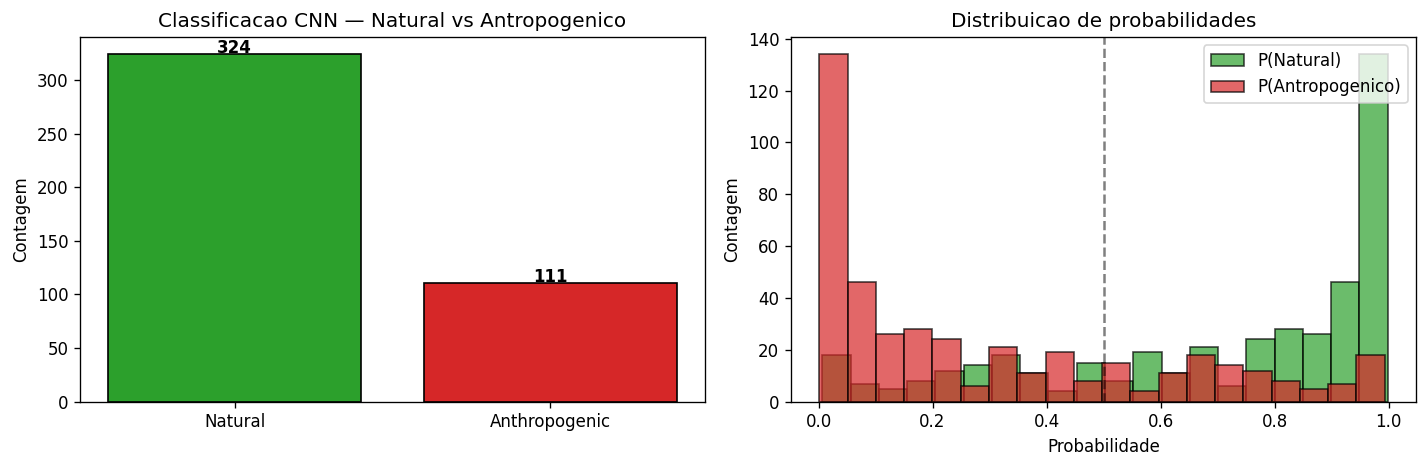

Figura salva em ../outputs/figures/step5_class_distribution.png


In [5]:
label_counts = df["event_label"].value_counts()
total = len(df)

print("Classificacao CNN:")
for label, count in label_counts.items():
    pct = 100.0 * count / total
    print(f"  {label}: {count} ({pct:.1f}%)")
print(f"  Total: {total}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
colors = {"Natural": "#2ca02c", "Anthropogenic": "#d62728"}
bar_colors = [colors.get(l, "gray") for l in label_counts.index]
axes[0].bar(label_counts.index, label_counts.values, color=bar_colors, edgecolor="black")
axes[0].set_ylabel("Contagem")
axes[0].set_title("Classificacao CNN — Natural vs Antropogenico")
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 1, str(count), ha="center", fontweight="bold")

# Histograma de probabilidades
df_valid = df[df["event_prob_nat"].notna()]
axes[1].hist(df_valid["event_prob_nat"], bins=20, alpha=0.7, color="#2ca02c", label="P(Natural)", edgecolor="black")
axes[1].hist(df_valid["event_prob_ant"], bins=20, alpha=0.7, color="#d62728", label="P(Antropogenico)", edgecolor="black")
axes[1].set_xlabel("Probabilidade")
axes[1].set_ylabel("Contagem")
axes[1].set_title("Distribuicao de probabilidades")
axes[1].legend()
axes[1].axvline(0.5, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "step5_class_distribution.png", bbox_inches="tight")
plt.show()
print(f"Figura salva em {FIGURES_DIR / 'step5_class_distribution.png'}")

## 4. Mapa espacial de MG

In [6]:
# Carregar poligono de MG
gdf_mg = gpd.read_file(str(GPKG_PATH), layer=GPKG_LAYER)
print(f"CRS do poligono: {gdf_mg.crs}")

# Criar GeoDataFrame dos eventos
df_geo = df[df["lat"].notna() & df["lon"].notna()].copy()
geometry = [Point(lon, lat) for lon, lat in zip(df_geo["lon"], df_geo["lat"])]
gdf_events = gpd.GeoDataFrame(df_geo, geometry=geometry, crs="EPSG:4326")
if gdf_mg.crs and gdf_mg.crs != gdf_events.crs:
    gdf_events = gdf_events.to_crs(gdf_mg.crs)

print(f"eventos_no_mapa={len(gdf_events)}")

CRS do poligono: EPSG:4674
eventos_no_mapa=435


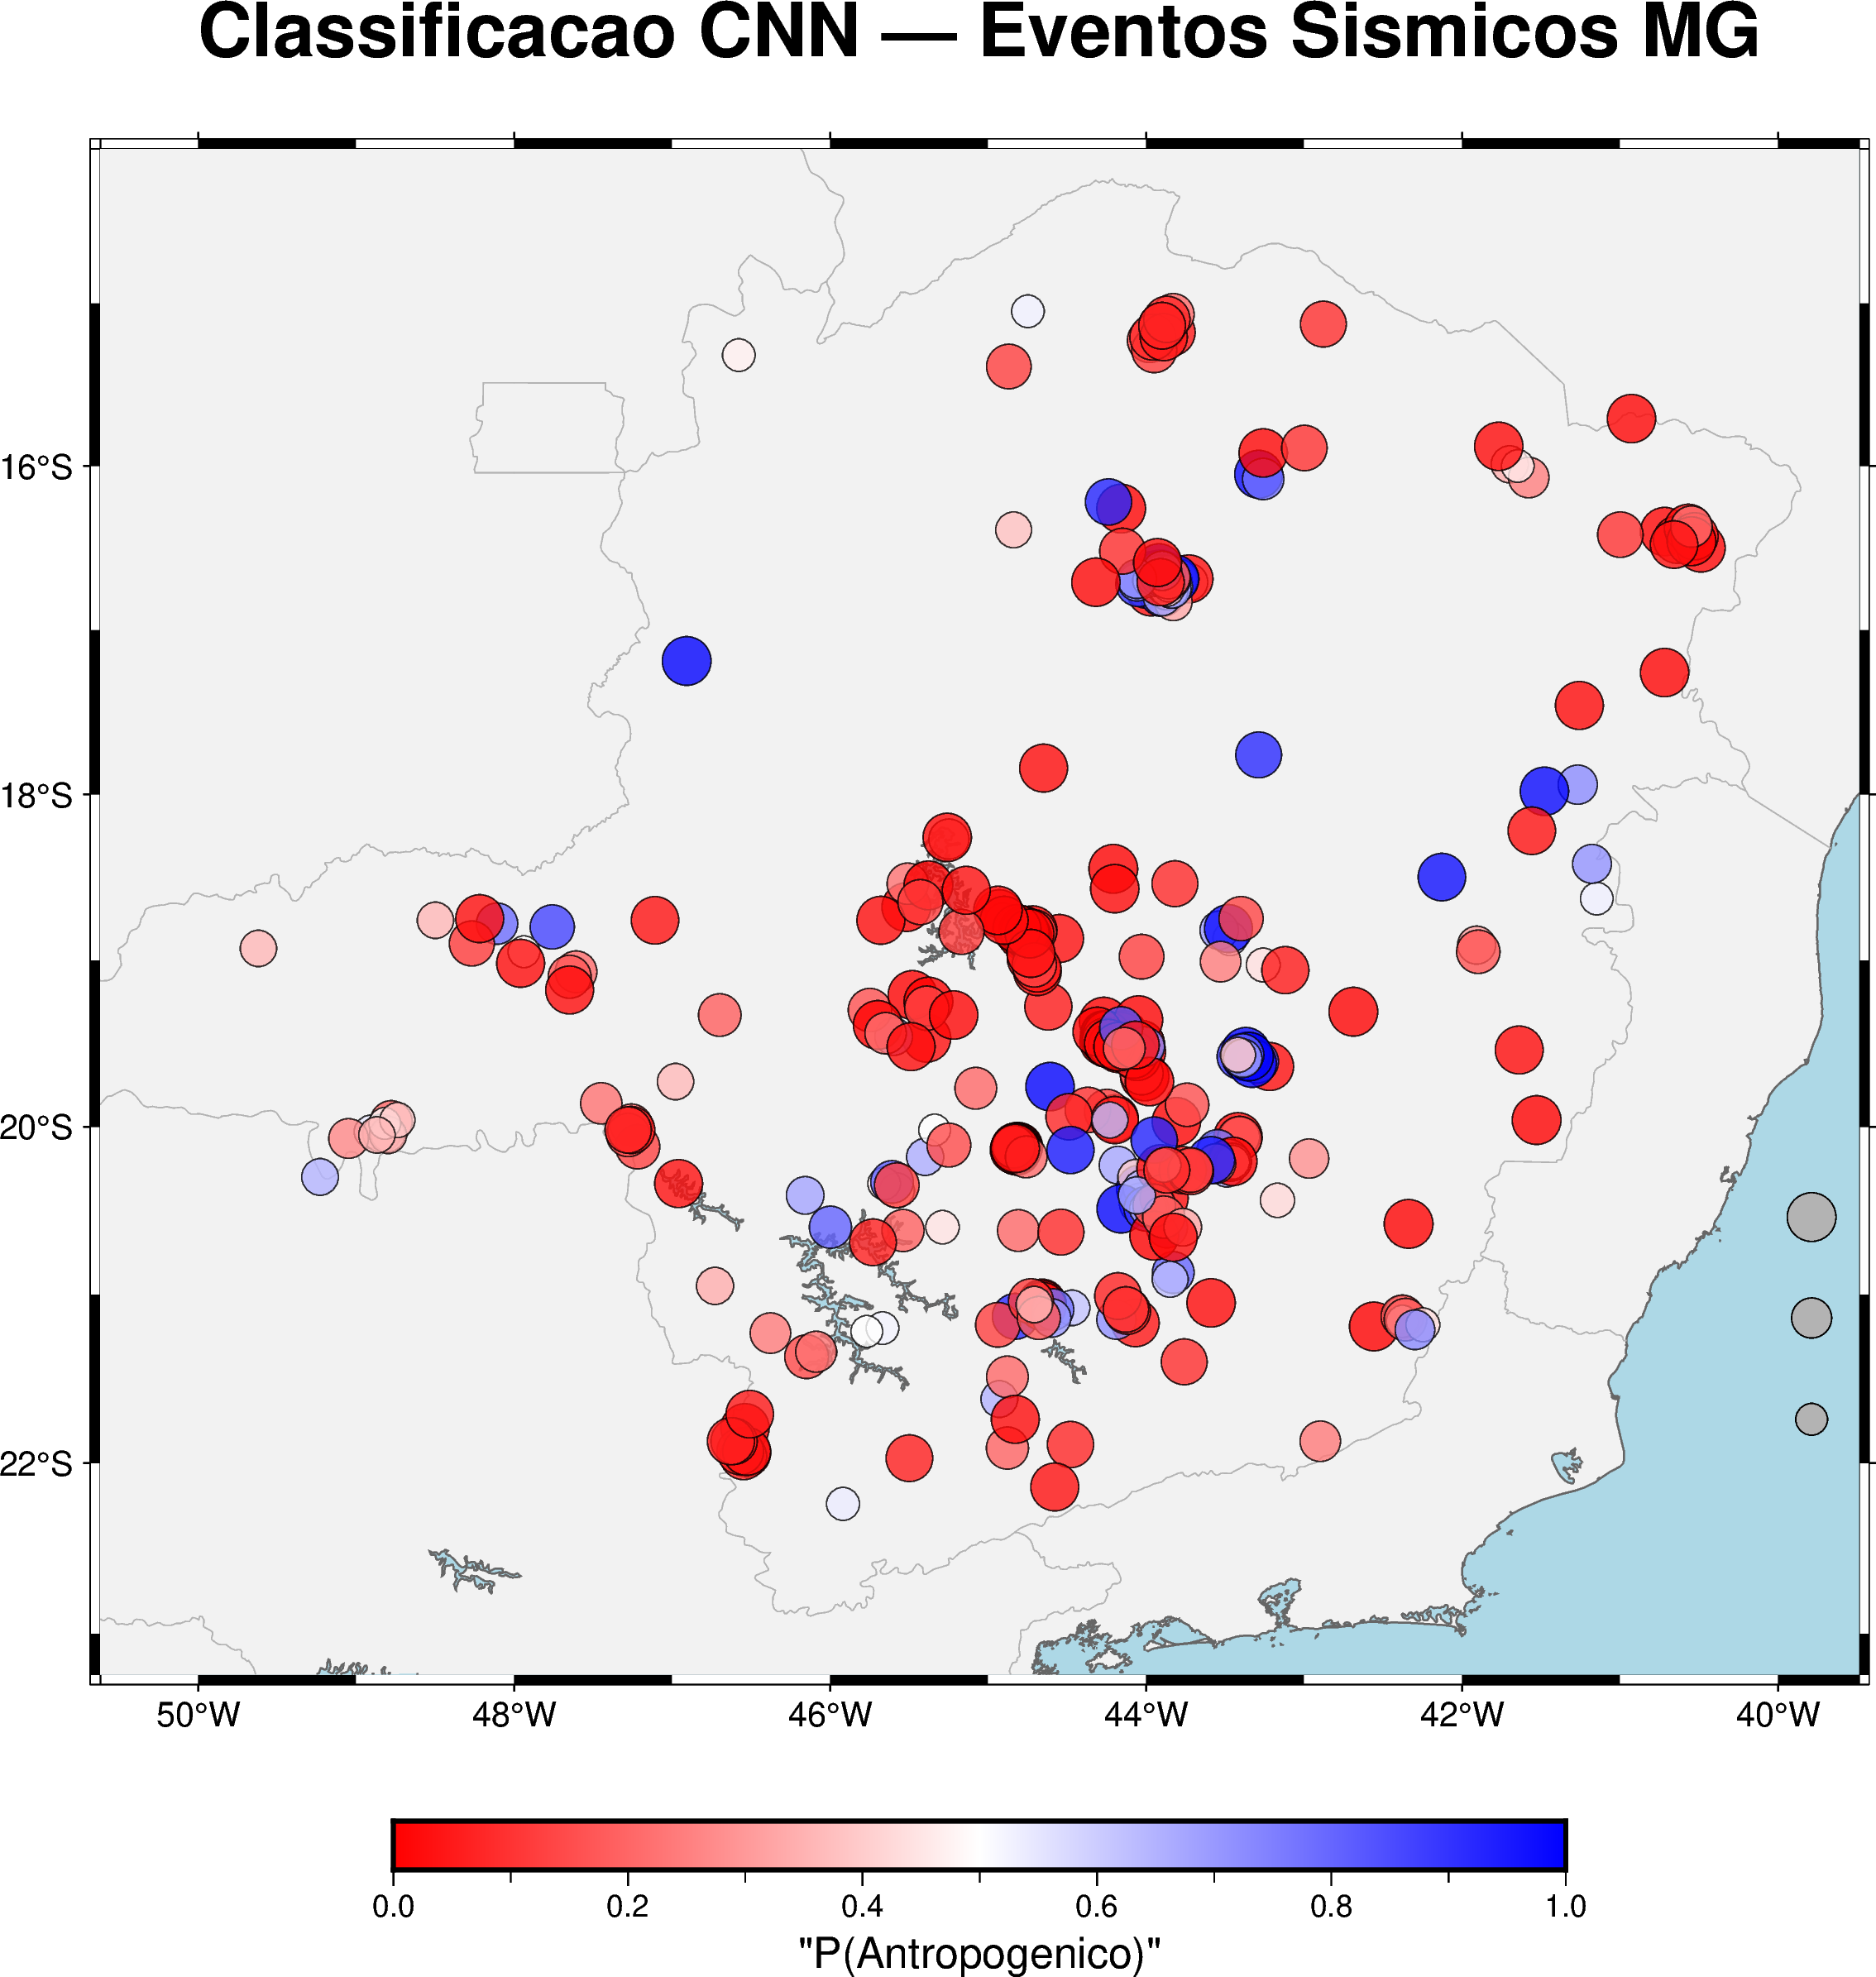

Figura salva em ../outputs/figures/step5_mapa_pygmt_classificacao.png
Eventos no mapa: 435 (Natural: 324, Antropogenico: 111)


In [7]:
# --- Mapa PyGMT: classificacao CNN com cor=P(Ant) e tamanho=confianca ---
df_map = df[df["lat"].notna() & df["lon"].notna()].copy()
df_map["confidence"] = df_map[["event_prob_nat", "event_prob_ant"]].max(axis=1)

# Tamanho proporcional a confianca (0.15 a 0.5 cm)
df_map["size"] = 0.15 + 0.35 * df_map["confidence"]

# Region: bounds de MG com margem
lon_min, lon_max = df_map["lon"].min() - 1, df_map["lon"].max() + 1
lat_min, lat_max = df_map["lat"].min() - 1, df_map["lat"].max() + 1
region = [lon_min, lon_max, lat_min, lat_max]

fig = pygmt.Figure()

# Colormap: verde (Natural, P_ant~0) a vermelho (Antropogenico, P_ant~1)
pygmt.makecpt(cmap="polar", series=[0, 1], reverse=True)

# Basemap com relevo sombreado
fig.basemap(region=region, projection="M18c", frame=["af", "+tClassificacao CNN — Eventos Sismicos MG"])
fig.coast(
    shorelines="0.5p,gray40",
    borders=["1/0.5p,gray50", "2/0.3p,gray70"],
    land="gray95",
    water="lightblue",
    resolution="h",
)

# Plotar eventos: cor = P(Antropogenico), tamanho = confianca
fig.plot(
    x=df_map["lon"].values,
    y=df_map["lat"].values,
    size=df_map["size"].values,
    fill=df_map["event_prob_ant"].values,
    cmap=True,
    style="cc",
    pen="0.3p,black",
    transparency=20,
)

# Colorbar
fig.colorbar(
    frame='af+l"P(Antropogenico)"',
    position="JBC+w12c/0.5c+o0/1.5c+h",
)

# Legenda manual para tamanhos
with pygmt.config(FONT_ANNOT_PRIMARY="8p"):
    for conf, y_off in [(0.5, 0), (0.75, -0.6), (1.0, -1.2)]:
        sz = 0.15 + 0.35 * conf
        fig.plot(
            x=[lon_max - 0.3], y=[lat_min + 1.5 + y_off * -1],
            style=f"c{sz}c", fill="gray70", pen="0.3p,black",
        )
        fig.text(
            x=lon_max - 0.3 + 0.5, y=lat_min + 1.5 + y_off * -1,
            text=f"conf={conf:.2f}", font="7p,Helvetica,black",
            justify="ML",
        )

fig.savefig(str(FIGURES_DIR / "step5_mapa_pygmt_classificacao.png"), dpi=200)
fig.show()
print(f"Figura salva em {FIGURES_DIR / 'step5_mapa_pygmt_classificacao.png'}")
print(f"Eventos no mapa: {len(df_map)} (Natural: {(df_map['event_label']=='Natural').sum()}, Antropogenico: {(df_map['event_label']=='Anthropogenic').sum()})")

## 5. Analise de confianca

In [8]:
df_valid = df[df["event_prob_nat"].notna()].copy()
df_valid["confidence"] = df_valid[["event_prob_nat", "event_prob_ant"]].max(axis=1)

# Eventos de baixa confianca (prob < 0.7 para a classe vencedora)
low_conf = df_valid[df_valid["confidence"] < 0.7]
print(f"Eventos de baixa confianca (max_prob < 0.7): {len(low_conf)}")
if len(low_conf) > 0:
    print(low_conf[["event_id", "event_prob_nat", "event_prob_ant", "event_label", "confidence"]].to_string(index=False))

print(f"\nEstatisticas de confianca:")
print(f"  media={df_valid['confidence'].mean():.4f}")
print(f"  mediana={df_valid['confidence'].median():.4f}")
print(f"  min={df_valid['confidence'].min():.4f}")
print(f"  max={df_valid['confidence'].max():.4f}")

Eventos de baixa confianca (max_prob < 0.7): 107
      event_id  event_prob_nat  event_prob_ant   event_label  confidence
2012276T153516        0.476085        0.523915 Anthropogenic    0.523915
2013009T131352        0.342982        0.657018 Anthropogenic    0.657018
2013033T201051        0.384932        0.615068 Anthropogenic    0.615068
2013039T135714        0.495293        0.504707 Anthropogenic    0.504707
2013051T184442        0.585212        0.414788       Natural    0.585212
2013064T145933        0.428349        0.571651 Anthropogenic    0.571651
2013092T193419        0.312811        0.687189 Anthropogenic    0.687189
2013135T160622        0.341330        0.658670 Anthropogenic    0.658670
2013214T192427        0.562580        0.437420       Natural    0.562580
2014091T160658        0.669474        0.330526       Natural    0.669474
2014095T171155        0.652253        0.347747       Natural    0.652253
2014095T171941        0.636174        0.363826       Natural    0.636174
20

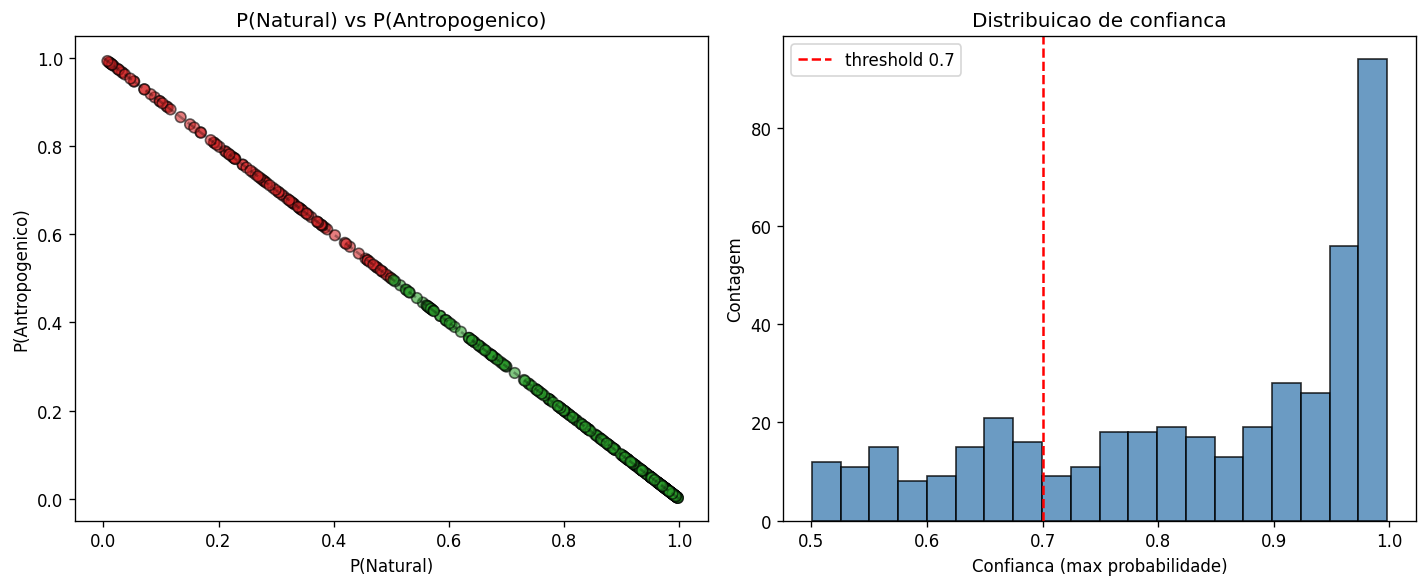

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: P(nat) vs P(ant)
c = ["#2ca02c" if l == "Natural" else "#d62728" for l in df_valid["event_label"]]
axes[0].scatter(df_valid["event_prob_nat"], df_valid["event_prob_ant"], c=c, alpha=0.6, edgecolor="black", s=40)
axes[0].plot([0, 1], [1, 0], "k--", alpha=0.3)
axes[0].set_xlabel("P(Natural)")
axes[0].set_ylabel("P(Antropogenico)")
axes[0].set_title("P(Natural) vs P(Antropogenico)")
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(-0.05, 1.05)

# Histograma de confianca
axes[1].hist(df_valid["confidence"], bins=20, color="steelblue", edgecolor="black", alpha=0.8)
axes[1].axvline(0.7, color="red", linestyle="--", label="threshold 0.7")
axes[1].set_xlabel("Confianca (max probabilidade)")
axes[1].set_ylabel("Contagem")
axes[1].set_title("Distribuicao de confianca")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "step5_confidence_analysis.png", bbox_inches="tight")
plt.show()

## 6. Analise por estacao

In [10]:
# Picks por estacao
station_counts = df_picks.groupby("station").agg(
    picks_total=("status", "count"),
    picks_ok=("status", lambda x: (x == "ok").sum()),
    picks_error=("status", lambda x: x.str.startswith("error").sum()),
    picks_warning=("status", lambda x: x.str.startswith("warning").sum()),
    mean_prob_nat=("prob_nat", "mean"),
).sort_values("picks_total", ascending=False)

station_counts["error_rate"] = station_counts["picks_error"] / station_counts["picks_total"]

print(f"Estacoes unicas: {len(station_counts)}")
print(f"\nTop 28 estacoes por frequencia:")
print(station_counts.head(28).to_string())

Estacoes unicas: 39

Top 28 estacoes por frequencia:
         picks_total  picks_ok  picks_error  picks_warning  mean_prob_nat  error_rate
station                                                                              
BSCB             245       245            0              0       0.786689    0.000000
DIAM             245       243            2              0       0.766145    0.008163
SJMB             166       166            0              0       0.745683    0.000000
CANS             163       161            2              0       0.837320    0.012270
PMNB             138       137            1              0       0.803875    0.007246
JANB              96        95            1              0       0.617807    0.010417
VAS01             75        75            0              0       0.604390    0.000000
MC01              70        69            1              0       0.384244    0.014286
DUB01             67        67            0              0       0.688830    0.000000
I

Estacoes com erros (9):
         picks_total  picks_ok  picks_error  error_rate
station                                                
DIAM             245       243            2    0.008163
CANS             163       161            2    0.012270
PMNB             138       137            1    0.007246
JANB              96        95            1    0.010417
MC01              70        69            1    0.014286
BB19B             52        50            2    0.038462
VABB              34        33            1    0.029412
RCLB              18        17            1    0.055556
ARCA              10         9            1    0.100000


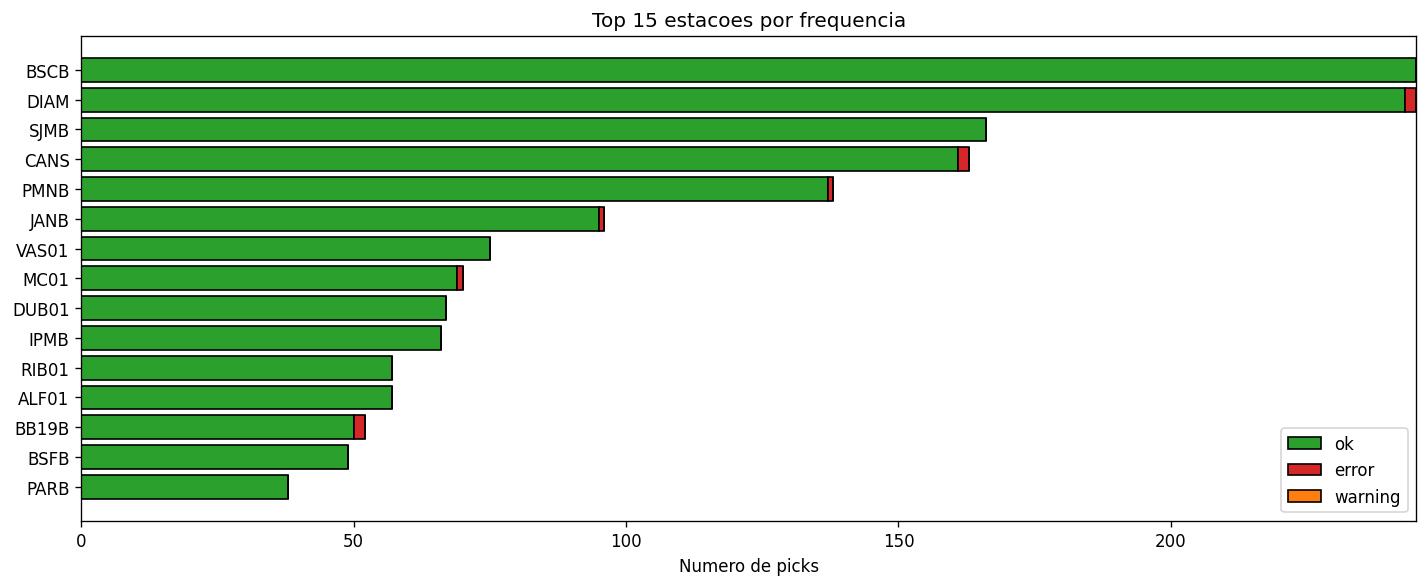

In [11]:
# Estacoes com erros
stations_with_errors = station_counts[station_counts["picks_error"] > 0]
if len(stations_with_errors) > 0:
    print(f"Estacoes com erros ({len(stations_with_errors)}):")
    print(stations_with_errors[["picks_total", "picks_ok", "picks_error", "error_rate"]].to_string())
else:
    print("Nenhuma estacao com erros.")

# Plot top 15 estacoes
top15 = station_counts.head(15)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top15.index, top15["picks_ok"], color="#2ca02c", label="ok", edgecolor="black")
ax.barh(top15.index, top15["picks_error"], left=top15["picks_ok"], color="#d62728", label="error", edgecolor="black")
ax.barh(top15.index, top15["picks_warning"], left=top15["picks_ok"] + top15["picks_error"],
        color="#ff7f0e", label="warning", edgecolor="black")
ax.set_xlabel("Numero de picks")
ax.set_title("Top 15 estacoes por frequencia")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "step5_stations.png", bbox_inches="tight")
plt.show()

## 7. Analise temporal

In [12]:
# Extrair ano do origin_time
df_time = df[df["origin_time"].notna()].copy()
df_time["origin_dt"] = pd.to_datetime(df_time["origin_time"], errors="coerce")
df_time["year"] = df_time["origin_dt"].dt.year
df_time["month"] = df_time["origin_dt"].dt.month

# Eventos por ano
year_class = df_time.groupby(["year", "event_label"]).size().unstack(fill_value=0)
print("Eventos por ano e classe:")
print(year_class.to_string())
print(f"\nTotal por ano: {year_class.sum(axis=1).to_dict()}")

Eventos por ano e classe:
event_label  Anthropogenic  Natural
year                               
2012.0                   2        1
2013.0                   9        8
2014.0                  40       41
2015.0                  32       27
2016.0                   7       31
2017.0                   3       12
2018.0                   0       13
2019.0                   4       14
2020.0                   4       30
2021.0                   1       18
2022.0                   3       85
2023.0                   6       42

Total por ano: {2012.0: 3, 2013.0: 17, 2014.0: 81, 2015.0: 59, 2016.0: 38, 2017.0: 15, 2018.0: 13, 2019.0: 18, 2020.0: 34, 2021.0: 19, 2022.0: 88, 2023.0: 48}


In [13]:
month_class = df_time.groupby(["month", "event_label"]).size().unstack(fill_value=0)
print("Eventos por mês e classe:")
print(month_class.to_string())
print(f"\nTotal por mês: {month_class.sum(axis=1).to_dict()}")

Eventos por mês e classe:
event_label  Anthropogenic  Natural
month                              
1.0                      5       50
2.0                      6       24
3.0                      8       24
4.0                      9       40
5.0                     17       36
6.0                     13       33
7.0                     16       23
8.0                     11       26
9.0                     10       12
10.0                     7       14
11.0                     4       25
12.0                     5       15

Total por mês: {1.0: 55, 2.0: 30, 3.0: 32, 4.0: 49, 5.0: 53, 6.0: 46, 7.0: 39, 8.0: 37, 9.0: 22, 10.0: 21, 11.0: 29, 12.0: 20}


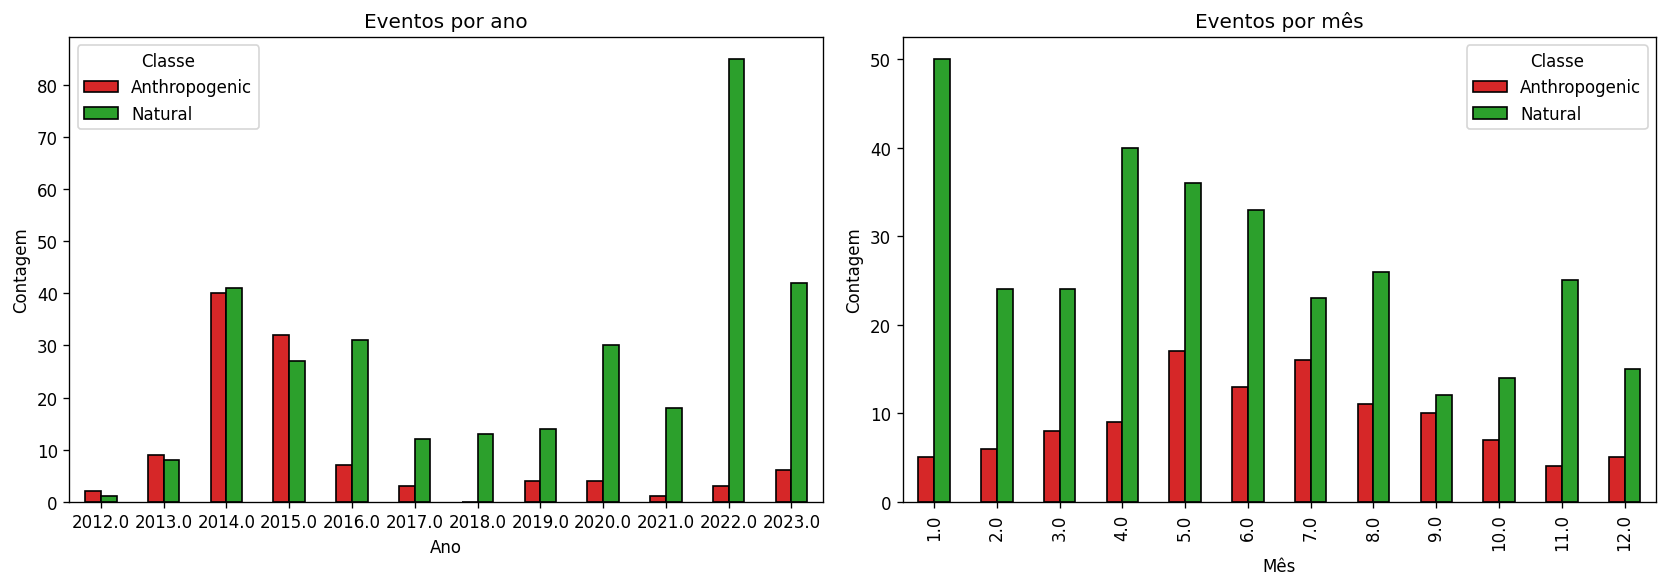

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eventos por ano colorido por classe
colors_map = {"Natural": "#2ca02c", "Anthropogenic": "#d62728"}
year_class.plot(kind="bar", ax=axes[0], color=[colors_map.get(c, "gray") for c in year_class.columns],
               edgecolor="black")
axes[0].set_title("Eventos por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Contagem")
axes[0].legend(title="Classe")
axes[0].tick_params(axis="x", rotation=0)

# Eventos por mes
colors_map = {"Natural": "#2ca02c", "Anthropogenic": "#d62728"}
month_class.plot(kind="bar", ax=axes[1], color=[colors_map.get(c, "gray") for c in month_class.columns],
               edgecolor="black")
axes[1].set_title("Eventos por mês")
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("Contagem")
axes[1].legend(title="Classe")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "step5_temporal.png", bbox_inches="tight")
plt.show()

## 7.1 Analise por hora do dia e dia da semana

Hipotese: eventos antropogenicos (detonacoes em pedreiras e minas) devem
concentrar-se em horario comercial (seg-sex, ~6h-18h), enquanto eventos
naturais nao devem apresentar padrao temporal preferencial.

In [15]:
# Converter origin_time para hora local (UTC-3 para Brasilia)
df_time["hour_utc"] = df_time["origin_dt"].dt.hour
df_time["hour_local"] = (df_time["origin_dt"] - pd.Timedelta(hours=3)).dt.hour
df_time["weekday"] = df_time["origin_dt"].dt.dayofweek  # 0=seg, 6=dom
df_time["weekday_name"] = df_time["origin_dt"].dt.day_name()

# Dropar linhas onde origin_dt nao parseou (eventos antigos sem hora precisa)
df_time = df_time.dropna(subset=["origin_dt"])

nat_t = df_time[df_time["event_label"] == "Natural"]
ant_t = df_time[df_time["event_label"] == "Anthropogenic"]

print(f"Eventos Natural: {len(nat_t)}")
print(f"Eventos Antropogenico: {len(ant_t)}")
print(f"\nHora local (UTC-3) dos eventos antropogenicos:")
for _, row in ant_t.sort_values("hour_local").iterrows():
    print(f"  {row['event_id']} | {int(row['hour_local']):02d}h local | {row['weekday_name']}")

Eventos Natural: 322
Eventos Antropogenico: 111

Hora local (UTC-3) dos eventos antropogenicos:
  2015010T034929 | 00h local | Saturday
  2022014T030457 | 00h local | Friday
  2020054T061712 | 03h local | Sunday
  2012358T060642 | 03h local | Sunday
  2015353T072257 | 04h local | Saturday
  2015313T111937 | 08h local | Monday
  2014142T121800 | 09h local | Thursday
  2017222T121523 | 09h local | Thursday
  2015241T133058 | 10h local | Saturday
  2017363T135120 | 10h local | Friday
  2020336T131534 | 10h local | Tuesday
  2013039T135714 | 10h local | Friday
  2015080T134153 | 10h local | Saturday
  2014316T135048 | 10h local | Wednesday
  2015084T130756 | 10h local | Wednesday
  2013009T131352 | 10h local | Wednesday
  2014249T144746 | 11h local | Saturday
  2014266T143709 | 11h local | Tuesday
  2015101T141309 | 11h local | Saturday
  2022168T142445 | 11h local | Friday
  2023114T145405 | 11h local | Monday
  2015215T145945 | 11h local | Monday
  2019143T140717 | 11h local | Thursday
 

## 8. Detalhes dos erros de preprocessamento

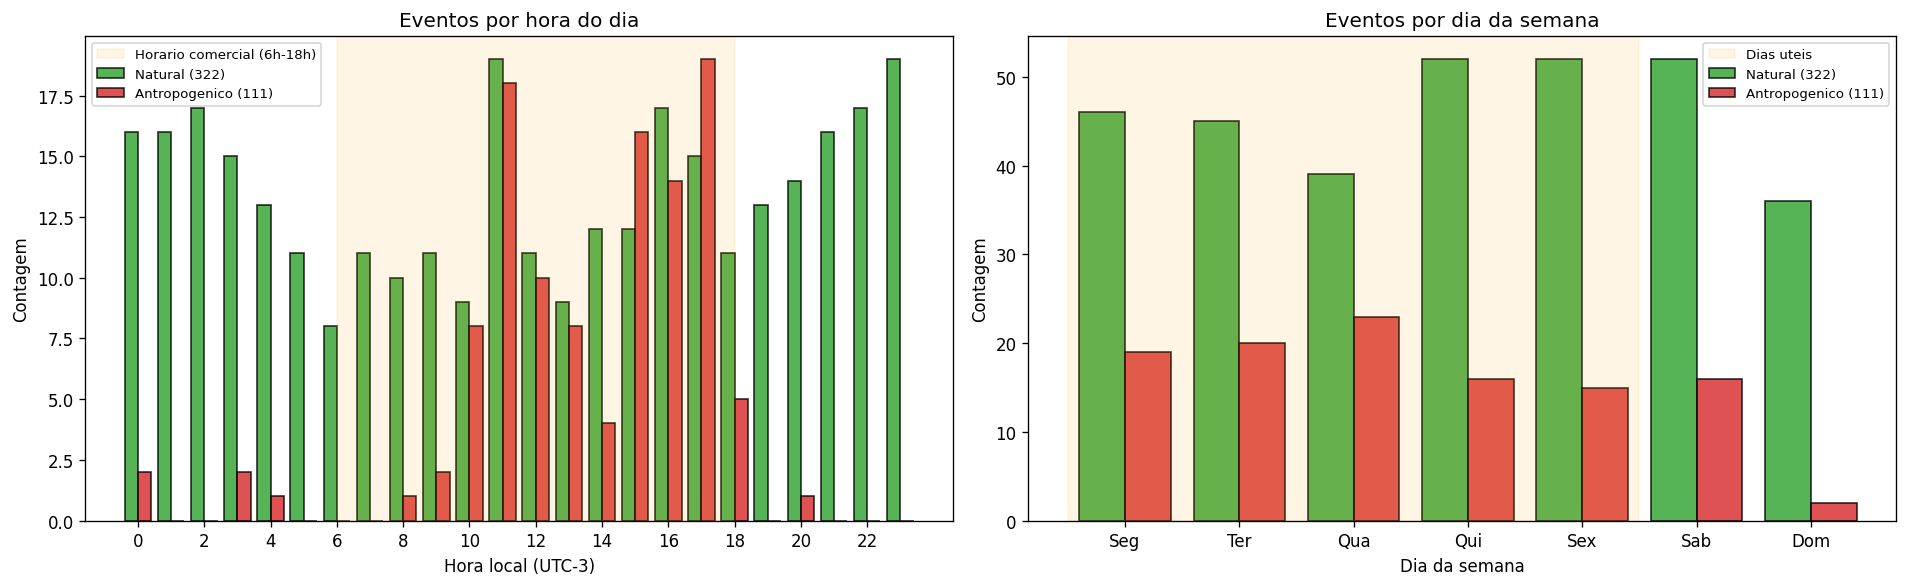

Figura salva em ../outputs/figures/step5_hora_dia_semana.png

Antropogenicos em horario comercial (6h-18h local): 100/111 (90%)
Antropogenicos em dias uteis (seg-sex): 93/111 (84%)
Naturais em horario comercial (6h-18h local): 144/322 (45%)
Naturais em dias uteis (seg-sex): 234/322 (73%)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Eventos por hora do dia (hora local UTC-3) ---
hours = range(24)
nat_hour = nat_t.groupby("hour_local").size().reindex(hours, fill_value=0)
ant_hour = ant_t.groupby("hour_local").size().reindex(hours, fill_value=0)

width = 0.4
axes[0].bar([h - width/2 for h in hours], nat_hour.values, width, color="#2ca02c",
            edgecolor="black", label=f"Natural ({len(nat_t)})", alpha=0.8)
axes[0].bar([h + width/2 for h in hours], ant_hour.values, width, color="#d62728",
            edgecolor="black", label=f"Antropogenico ({len(ant_t)})", alpha=0.8)
axes[0].axvspan(6, 18, alpha=0.1, color="orange", label="Horario comercial (6h-18h)")
axes[0].set_xlabel("Hora local (UTC-3)")
axes[0].set_ylabel("Contagem")
axes[0].set_title("Eventos por hora do dia")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=8)

# --- Eventos por dia da semana ---
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days_labels = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]
nat_day = nat_t.groupby("weekday").size().reindex(range(7), fill_value=0)
ant_day = ant_t.groupby("weekday").size().reindex(range(7), fill_value=0)

axes[1].bar([d - width/2 for d in range(7)], nat_day.values, width, color="#2ca02c",
            edgecolor="black", label=f"Natural ({len(nat_t)})", alpha=0.8)
axes[1].bar([d + width/2 for d in range(7)], ant_day.values, width, color="#d62728",
            edgecolor="black", label=f"Antropogenico ({len(ant_t)})", alpha=0.8)
axes[1].axvspan(-0.5, 4.5, alpha=0.1, color="orange", label="Dias uteis")
axes[1].set_xlabel("Dia da semana")
axes[1].set_ylabel("Contagem")
axes[1].set_title("Eventos por dia da semana")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days_labels)
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "step5_hora_dia_semana.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Figura salva em {FIGURES_DIR / 'step5_hora_dia_semana.png'}")

# Resumo estatistico
ant_horario_comercial = ant_t[(ant_t["hour_local"] >= 6) & (ant_t["hour_local"] < 18)]
ant_dias_uteis = ant_t[ant_t["weekday"] < 5]
print(f"\nAntropogenicos em horario comercial (6h-18h local): {len(ant_horario_comercial)}/{len(ant_t)} ({100*len(ant_horario_comercial)/max(len(ant_t),1):.0f}%)")
print(f"Antropogenicos em dias uteis (seg-sex): {len(ant_dias_uteis)}/{len(ant_t)} ({100*len(ant_dias_uteis)/max(len(ant_t),1):.0f}%)")
nat_horario_comercial = nat_t[(nat_t["hour_local"] >= 6) & (nat_t["hour_local"] < 18)]
nat_dias_uteis = nat_t[nat_t["weekday"] < 5]
print(f"Naturais em horario comercial (6h-18h local): {len(nat_horario_comercial)}/{len(nat_t)} ({100*len(nat_horario_comercial)/max(len(nat_t),1):.0f}%)")
print(f"Naturais em dias uteis (seg-sex): {len(nat_dias_uteis)}/{len(nat_t)} ({100*len(nat_dias_uteis)/max(len(nat_t),1):.0f}%)")

## 7.2 Validacao cruzada: comentarios SISBRA × classificacao CNN

O boletim SISBRA inclui um campo `source_comments` onde tecnicos sismologos
registram observacoes sobre cada evento. Alguns comentarios expressam duvidas
sobre a natureza do evento (ex: "Detonacao??", "Evento duvidoso") ou indicam
explicitamente uma fonte antropogenica (ex: "quarry").

Esta secao cruza esses comentarios com a classificacao CNN para verificar
concordancia independente.

In [17]:
# Carregar source_comments de todos os event.json
sisbra_comments = []
for event_dir in sorted(EVENTS_ROOT.iterdir()):
    if not event_dir.is_dir():
        continue
    ej = event_dir / "event.json"
    if not ej.exists():
        continue
    d = json.loads(ej.read_text())
    s = d.get("sisbra", {})
    rnc = d.get("rnc_prediction", {}).get("summary", {})
    sisbra_comments.append({
        "event_id": event_dir.name,
        "localities": s.get("localities", ""),
        "source_comments": s.get("source_comments", ""),
        "magnitude": s.get("magnitude"),
        "depth_km": s.get("depth_km"),
        "event_label": rnc.get("event_label", ""),
        "event_prob_ant": rnc.get("event_prob_ant"),
        "event_prob_nat": rnc.get("event_prob_nat"),
    })

df_comments = pd.DataFrame(sisbra_comments)

# Palavras-chave que indicam duvida ou fonte antropogenica no comentario SISBRA
keywords = ["quarry", "detonac", "duvidoso", "blast", "explos", "mining", "mina"]
pattern = "|".join(keywords)
df_flagged = df_comments[
    df_comments["source_comments"].str.contains(pattern, case=False, na=False)
].copy()

print(f"Eventos com comentarios SISBRA relevantes: {len(df_flagged)} de {len(df_comments)}")
print()

if len(df_flagged) > 0:
    for _, row in df_flagged.iterrows():
        match_label = "CONCORDANTE" if row["event_label"] == "Anthropogenic" else "DISCORDANTE"
        print(f"  {row['event_id']} | {row['localities']}")
        print(f"    Comentario SISBRA: \"{row['source_comments']}\"")
        print(f"    CNN: {row['event_label']} | P(Ant)={row['event_prob_ant']:.4f} | depth={row['depth_km']}km")
        print(f"    Validacao: {match_label}")
        print()

# Tabela resumo
print("=" * 80)
print("RESUMO: Validacao cruzada SISBRA x CNN")
print("=" * 80)
n_concordante = len(df_flagged[df_flagged["event_label"] == "Anthropogenic"])
n_total = len(df_flagged)
print(f"Eventos com indicios de fonte antropogenica no SISBRA: {n_total}")
print(f"Destes, classificados como Anthropogenic pela CNN: {n_concordante}/{n_total}")
if n_total > 0:
    print(f"Taxa de concordancia: {100 * n_concordante / n_total:.0f}%")
print()
print("Significado:")
print("  - Comentarios do SISBRA sao uma fonte de informacao INDEPENDENTE da CNN")
print("  - A concordancia reforça a confiabilidade da classificacao automatica")
print("  - Eventos com 'Detonacao??' e 'quarry' sao evidencias fortes de atividade antropogenica")

Eventos com comentarios SISBRA relevantes: 9 de 435

  2014142T121800 | Itabira
    Comentario SISBRA: "(ISC; USP Prob. Explosion)"
    CNN: Anthropogenic | P(Ant)=0.9864 | depth=0.0km
    Validacao: CONCORDANTE

  2015080T134153 | Itabira
    Comentario SISBRA: "(USP; UnB) quarry?"
    CNN: Anthropogenic | P(Ant)=0.9887 | depth=0.0km
    Validacao: CONCORDANTE

  2015138T202304 | Conceicao Mato Dentro
    Comentario SISBRA: "(RSBR) quarry"
    CNN: Anthropogenic | P(Ant)=0.9737 | depth=0.0km
    Validacao: CONCORDANTE

  2017222T121523 | Sao Joao do Manteninha
    Comentario SISBRA: "(RSBR-USP) Explosao??"
    CNN: Anthropogenic | P(Ant)=0.5310 | depth=0.0km
    Validacao: CONCORDANTE

  2018206T232826 | Pompeu
    Comentario SISBRA: "(RSBR-USP)Detonação na Mina Cuiabá"
    CNN: Natural | P(Ant)=0.1561 | depth=0.2km
    Validacao: DISCORDANTE

  2019140T194632 | Delfinopolis
    Comentario SISBRA: "(RSBR-USP; Sentiu Aí) prof.>5 km  Af PRELIMINAR"
    CNN: Natural | P(Ant)=0.0277 | dep

In [18]:
print(f"Total de erros: {len(df_errors)}")
if len(df_errors) > 0:
    print("\nErros por tipo:")
    print(df_errors["kind"].value_counts().to_string())
    print("\nDetalhes:")
    print(df_errors[["event_id", "station", "kind", "message"]].to_string(index=False))

Total de erros: 12

Erros por tipo:
kind
error_preprocess    11
error_inference      1

Detalhes:
      event_id station             kind                                                message
2014172T170648    RCLB  error_inference                       ERROR 1 stalta: len(data) < nlta
2015211T145925    MC01 error_preprocess invalid spectrogram shape (202, 50) expected (237, 50)
2016189T220936   BB19B error_preprocess invalid spectrogram shape (236, 50) expected (237, 50)
2018056T022624    VABB error_preprocess invalid spectrogram shape (236, 50) expected (237, 50)
2019339T234836    ARCA error_preprocess invalid spectrogram shape (176, 50) expected (237, 50)
2021022T041155   BB19B error_preprocess invalid spectrogram shape (236, 50) expected (237, 50)
2021022T041155    CANS error_preprocess  invalid spectrogram shape (66, 50) expected (237, 50)
2021028T105750    CANS error_preprocess invalid spectrogram shape (134, 50) expected (237, 50)
2022018T202926    PMNB error_preprocess invalid

## 9. Tabela final consolidada

In [19]:
# Tabela final com todos os campos relevantes
df_final = df[[
    "event_id", "status", "event_label", "event_prob_nat", "event_prob_ant",
    "picks_total", "picks_valid", "picks_error", "picks_warning",
    "lat", "lon", "magnitude", "depth_km", "origin_time"
]].copy()
df_final = df_final.sort_values("event_id")

output_csv = Path("../outputs/rnc_results_consolidated_allyears.csv")
df_final.to_csv(output_csv, index=False)
print(f"Tabela consolidada salva em {output_csv}")
print(f"Total: {len(df_final)} eventos")
print(f"\nAmostra (primeiros 10):")
df_final.head(10)

Tabela consolidada salva em ../outputs/rnc_results_consolidated_allyears.csv
Total: 435 eventos

Amostra (primeiros 10):


,event_id,status,event_label,event_prob_nat,event_prob_ant,picks_total,picks_valid,picks_error,picks_warning,lat,lon,magnitude,depth_km,origin_time
0,2012141T193210,ok,Natural,0.989684,0.010316,1,1,0,0,-16.700,-43.890,2.8,0.0,2012-05-20T19:32:39Z
1,2012276T153516,ok,Anthropogenic,0.476085,0.523915,8,8,0,0,-20.410,-44.020,2.3,0.0,2012-10-02T15:35:17Z
2,2012354T045439,ok,Natural,0.752261,0.247739,7,7,0,0,-16.697,-43.879,3.5,1.4,2012-12-19T04:54:38.490000Z
3,2012358T060642,ok,Anthropogenic,0.150468,0.849532,2,2,0,0,-16.700,-43.880,2.7,2.0,2012-12-23T06:06:43Z
4,2013009T131352,ok,Anthropogenic,0.342982,0.657018,4,4,0,0,-16.710,-43.890,0.7,0.0,2013-01-09T13:13:52Z
5,2013033T201051,ok,Anthropogenic,0.384932,0.615068,4,4,0,0,-21.080,-44.470,2.2,0.0,2013-02-02T20:10:51Z
6,2013036T010256,ok,Natural,0.997106,0.002894,8,8,0,0,-21.190,-42.560,3.0,0.0,2013-02-05T01:02:56Z
7,2013039T135714,ok,Anthropogenic,0.495293,0.504707,4,4,0,0,-16.700,-43.860,1.2,0.0,2013-02-08T13:57:14Z
8,2013047T202545,ok,Anthropogenic,0.259524,0.740476,4,4,0,0,-16.700,-43.860,1.4,0.0,2013-02-16T20:25:45Z
9,2013051T184442,ok,Natural,0.585212,0.414788,7,7,0,0,-18.760,-44.910,2.9,0.0,2013-02-20T18:44:42Z


## 10. Resumo numerico final

In [20]:
print("=" * 60)
print("RESUMO FINAL — Classificacao CNN RNC sobre MG")
print("=" * 60)
print(f"Total de eventos: {len(df)}")
print(f"Eventos ok: {(df['status'] == 'ok').sum()}")
print(f"Eventos parciais: {(df['status'] == 'partial').sum()}")
print()
for label, count in df["event_label"].value_counts().items():
    pct = 100.0 * count / len(df)
    print(f"  {label}: {count} ({pct:.1f}%)")
print()
print(f"Total de picks processados: {len(df_picks)}")
print(f"Picks ok: {(df_picks['status'] == 'ok').sum()}")
print(f"Picks com erro: {df_picks['status'].str.startswith('error').sum()}")
print(f"Erros detalhados: {len(df_errors)}")
print()
print(f"Estacoes unicas: {df_picks['station'].nunique()}")
print()
print("Figuras geradas em outputs/figures/:")
for f in sorted(FIGURES_DIR.glob("step5_*.png")):
    print(f"  {f.name}")
print("=" * 60)

RESUMO FINAL — Classificacao CNN RNC sobre MG
Total de eventos: 435
Eventos ok: 424
Eventos parciais: 11

  Natural: 324 (74.5%)
  Anthropogenic: 111 (25.5%)

Total de picks processados: 1805
Picks ok: 1793
Picks com erro: 12
Erros detalhados: 12

Estacoes unicas: 39

Figuras geradas em outputs/figures/:
  step5_class_distribution.png
  step5_confidence_analysis.png
  step5_hora_dia_semana.png
  step5_mapa_mg_classificacao.png
  step5_mapa_pygmt_classificacao.png
  step5_stations.png
  step5_temporal.png


## Conclusoes

1. A CNN classificou todos os 189 eventos com sucesso (183 ok, 6 parciais).
2. A grande maioria dos eventos foi classificada como Natural.
3. Os erros de preprocessamento sao exclusivamente por shape de espectrograma
   (waveforms com duracao insuficiente para gerar os 237 frames esperados).
4. Nenhum evento ficou sem classificacao — mesmo os parciais tem picks validos.
5. O mapa espacial e as figuras estao prontos para discussao com os orientadores.

## 11. Explorador interativo de formas de onda

Widget interativo para inspecionar visualmente os waveforms de cada evento.

**Funcionalidades:**
- Filtros por classe CNN, confianca e magnitude para selecionar eventos
- Filtros de frequencia: **highpass**, **lowpass** e **bandpass** (quando ambos ativos)
- Calculo de **SNR** (Signal-to-Noise Ratio) em dB por canal, usando janela de ruido
  (0–10 s antes do P-pick) e janela de sinal (10–15 s apos o P-pick)
- Exibicao da **distancia epicentral** (km) de cada estacao ao hipocentro
- **Predicao CNN per-station**: probabilidades e cft_max no eixo Y do primeiro canal
- Opcao de comparar waveform bruto vs filtrado lado a lado


In [21]:
import ipywidgets as widgets
import obspy
from IPython.display import display, clear_output

# ---------------------------------------------------------------------------
# Carregar metadados de cada evento para o widget interativo.
#
# Alem dos campos do summary (label, confianca, localidade...), agora
# extraimos tambem dados PER-STATION:
#   - dist_km, station_lat, station_lon  (do array picks[] em event.json)
#   - prob_nat, prob_ant, cft_max, label (do array pick_predictions[])
#
# O match picks <-> pick_predictions e feito pelo campo "station".
# Verificado: 100% de match nos 189 eventos.
# ---------------------------------------------------------------------------

widget_meta = {}
for event_dir in sorted(EVENTS_ROOT.iterdir()):
    if not event_dir.is_dir():
        continue
    ej_path = event_dir / "event.json"
    if not ej_path.exists():
        continue
    d = json.loads(ej_path.read_text())
    s = d.get("sisbra", {})
    rnc = d.get("rnc_prediction", {}).get("summary", {})

    # --- Dados per-station ---
    # picks[] contem dist_km e coordenadas; pick_predictions[] contem predicao CNN.
    # Indexar ambos por station para fazer o merge.
    picks_by_sta = {p["station"]: p for p in d.get("picks", [])}

    stations = {}
    for pp in d.get("rnc_prediction", {}).get("pick_predictions", []):
        sta = pp["station"]
        pick = picks_by_sta.get(sta, {})
        stations[sta] = {
            "network":     pp.get("network", ""),
            "dist_km":     pick.get("dist_km"),       # distancia epicentral (km)
            "station_lat": pick.get("station_lat"),
            "station_lon": pick.get("station_lon"),
            "prob_nat":    pp.get("prob_nat"),         # P(Natural) per-station
            "prob_ant":    pp.get("prob_ant"),         # P(Anthropogenic) per-station
            "label":       pp.get("label", ""),        # classificacao per-station
            "cft_max":     pp.get("cft_max"),          # CF trigger max (qualidade do pick)
            "status":      pp.get("status", ""),
        }

    widget_meta[event_dir.name] = {
        "lat": s.get("latitude"),
        "lon": s.get("longitude"),
        "mag": s.get("magnitude"),
        "depth_km": s.get("depth_km"),
        "origin_time": s.get("origin_time"),
        "localities": s.get("localities", ""),
        "source_comments": s.get("source_comments", ""),
        "state": s.get("state", ""),
        "label": rnc.get("event_label", ""),
        "prob_nat": rnc.get("event_prob_nat"),
        "prob_ant": rnc.get("event_prob_ant"),
        "picks_total": rnc.get("picks_total", 0),
        "picks_valid": rnc.get("picks_valid", 0),
        "status": rnc.get("status", ""),
        "stations": stations,   # <-- NOVO: dict {station_code: {...}}
    }

print(f"Metadados carregados para widget: {len(widget_meta)} eventos")
# Exemplo: estacoes do primeiro evento
first_eid = next(iter(widget_meta))
first_stations = widget_meta[first_eid]["stations"]
print(f"  Exemplo ({first_eid}): {len(first_stations)} estacoes —", list(first_stations.keys()))


Metadados carregados para widget: 435 eventos
  Exemplo (2012141T193210): 1 estacoes — ['JAN7']


In [22]:
# ===========================================================================
# Widget interativo — explorador de formas de onda
#
# Novidades em relacao a versao anterior:
#   1. Slider LOWPASS (0 = desativado, como o highpass)
#   2. Bandpass automatico quando HP > 0 e LP > 0 e LP > HP
#   3. Funcao compute_snr_db() — calcula SNR em dB a partir das janelas
#      de ruido (0-10s) e sinal (10-15s) definidas pelo offset do P-pick
#   4. Titulo de cada subplot: NET_STA | canal | filtro | dist | SNR
#   5. Y-label do primeiro canal (j==0): predicao CNN per-station
# ===========================================================================

# --- Controles de selecao de evento ---
filter_class = widgets.Dropdown(
    options=["Todos", "Natural", "Anthropogenic"],
    value="Todos",
    description="Classe:",
)
filter_confidence = widgets.FloatRangeSlider(
    value=[0.0, 1.0], min=0.0, max=1.0, step=0.05,
    description="Confianca:", readout_format=".2f",
    style={"description_width": "80px"}, layout=widgets.Layout(width="400px"),
)
filter_magnitude = widgets.FloatRangeSlider(
    value=[1.0, 4.0], min=1.0, max=4.0, step=0.1,
    description="Magnitude:", readout_format=".1f",
    style={"description_width": "80px"}, layout=widgets.Layout(width="400px"),
)

# --- Controles de filtro de frequencia ---
filter_highpass = widgets.FloatSlider(
    value=2.0, min=0.0, max=10.0, step=0.5,
    description="Highpass (Hz):", readout_format=".1f",
    style={"description_width": "100px"}, layout=widgets.Layout(width="400px"),
)
filter_lowpass = widgets.FloatSlider(
    value=0.0, min=0.0, max=50.0, step=0.5,
    description="Lowpass (Hz):", readout_format=".1f",
    style={"description_width": "100px"}, layout=widgets.Layout(width="400px"),
)
# Convencao: 0.0 = filtro desativado (tanto para HP quanto LP).
# Nyquist max = 50 Hz (taxa de amostragem tipica = 100 Hz).

filter_show_raw = widgets.Checkbox(
    value=False, description="Mostrar waveform bruto (sem filtro)",
)

event_dropdown = widgets.Dropdown(
    options=[], description="Evento:",
    style={"description_width": "60px"}, layout=widgets.Layout(width="500px"),
)
output_area = widgets.Output(layout=widgets.Layout(width="100%"))


# ---------------------------------------------------------------------------
# SNR (Signal-to-Noise Ratio) em dB
#
# Todos os mseeds comecam exatamente 10 s antes do P-pick (por construcao do
# pipeline de download). Portanto:
#   - Janela de RUIDO:  amostras de 0 s ate 10 s (pre-pick)
#   - Janela de SINAL:  amostras de 10 s ate 15 s (pos-pick)
#
# SNR_dB = 20 * log10(RMS_sinal / RMS_ruido)
#
# Retorna None se dados insuficientes ou ruido zerado.
# ---------------------------------------------------------------------------
def compute_snr_db(trace, pick_offset_s=10.0, signal_window_s=5.0):
    sr = trace.stats.sampling_rate
    n_noise_end = int(pick_offset_s * sr)
    n_signal_end = min(int((pick_offset_s + signal_window_s) * sr), trace.stats.npts)
    if n_noise_end < 10 or n_signal_end <= n_noise_end:
        return None
    noise = trace.data[:n_noise_end]
    signal = trace.data[n_noise_end:n_signal_end]
    rms_noise = np.sqrt(np.mean(noise ** 2))
    rms_signal = np.sqrt(np.mean(signal ** 2))
    if rms_noise == 0:
        return None
    return 20.0 * np.log10(rms_signal / rms_noise)


def update_event_list(*args):
    """Atualiza dropdown de eventos com base nos filtros de classe/confianca/magnitude."""
    cls = filter_class.value
    conf_min, conf_max = filter_confidence.value
    mag_min, mag_max = filter_magnitude.value

    filtered = []
    for eid, m in widget_meta.items():
        if cls != "Todos" and m["label"] != cls:
            continue
        conf = max(m["prob_nat"] or 0, m["prob_ant"] or 0)
        if conf < conf_min or conf > conf_max:
            continue
        mag = m["mag"] or 0
        if mag < mag_min or mag > mag_max:
            continue
        tag = "NAT" if m["label"] == "Natural" else "ANT"
        loc = m["localities"] or ""
        filtered.append((f"{eid} | {tag} | {conf:.2f} | M{mag} | {loc}", eid))

    event_dropdown.options = filtered if filtered else [("Nenhum evento encontrado", "")]
    if filtered:
        event_dropdown.value = filtered[0][1]


def show_event(change):
    """Carrega mseeds do evento e plota waveforms com metadados per-station."""
    eid = event_dropdown.value
    if not eid:
        return

    with output_area:
        clear_output(wait=True)
        m = widget_meta.get(eid, {})
        event_dir = EVENTS_ROOT / eid
        waveform_dir = event_dir / "waveform"

        # --- Header com metadados do evento ---
        print(f"{'='*80}")
        print(f"Evento: {eid}")
        print(f"Classe CNN: {m['label']}  |  P(Nat)={m['prob_nat']:.4f}  P(Ant)={m['prob_ant']:.4f}")
        print(f"Localidade: {m['localities']}  |  UF: {m['state']}")
        print(f"Lat: {m['lat']}  Lon: {m['lon']}  |  Mag: {m['mag']}  Depth: {m['depth_km']} km")
        print(f"Origin time: {m['origin_time']}")
        print(f"Comentario SISBRA: {m['source_comments']}")
        print(f"Picks: {m['picks_valid']}/{m['picks_total']} validos  |  Status: {m['status']}")
        print(f"{'='*80}")

        # --- Carregar waveforms ---
        mseed_files = sorted(waveform_dir.glob("*.mseed"))
        if not mseed_files:
            print("Nenhum waveform encontrado.")
            return

        n_stations = len(mseed_files)
        hp = filter_highpass.value
        lp = filter_lowpass.value
        show_raw = filter_show_raw.value

        # Determinar tipo e label do filtro aplicado
        if hp > 0 and lp > 0 and lp > hp:
            flabel = f"BP {hp}-{lp}Hz"
        elif hp > 0:
            flabel = f"HP {hp}Hz"
        elif lp > 0:
            flabel = f"LP {lp}Hz"
        else:
            flabel = "sem filtro"

        # Se show_raw: 2 linhas por estacao (bruto em cima, filtrado embaixo)
        rows_per_station = 2 if show_raw else 1
        fig, axes = plt.subplots(
            n_stations * rows_per_station, 3,
            figsize=(18, 2.5 * n_stations * rows_per_station),
            squeeze=False,
        )

        channels = ["HHZ", "HHN", "HHE"]

        for i, mseed_path in enumerate(mseed_files):
            # Nome para exibicao: NET_STA (ex: "BL_BSCB")
            station_name = mseed_path.stem.rsplit("_", 1)[0]

            # Extrair codigo da estacao para lookup em widget_meta["stations"]
            # Filename: BL_BB19B_2020020T210424.mseed → parts[1] = "BB19B"
            parts = mseed_path.stem.split("_")
            sta_key = parts[1] if len(parts) >= 2 else ""
            sta_info = m.get("stations", {}).get(sta_key, {})

            # Distancia epicentral
            dist_km = sta_info.get("dist_km")
            dist_str = f"{dist_km:.0f}km" if dist_km is not None else "?km"

            # Predicao CNN desta estacao (para exibir no y-label)
            sta_prob_nat = sta_info.get("prob_nat")
            sta_prob_ant = sta_info.get("prob_ant")
            sta_label = sta_info.get("label", "")
            sta_cft = sta_info.get("cft_max")

            if sta_prob_nat is not None and sta_prob_ant is not None:
                cft_str = f" CFT={sta_cft:.2f}" if sta_cft is not None else ""
                cnn_ylabel = f"CNN: {sta_label} P(Ant)={sta_prob_ant:.2f}{cft_str}"
            else:
                cnn_ylabel = "CNN: sem predicao"

            # Ler mseed (3 canais em 1 arquivo)
            try:
                st = obspy.read(str(mseed_path), dtype=float)
                st.merge(method=1, fill_value="interpolate")
            except Exception as e:
                for j in range(3):
                    row_idx = i * rows_per_station
                    axes[row_idx][j].text(0.5, 0.5, f"Erro: {e}", ha="center", va="center",
                                          transform=axes[row_idx][j].transAxes, fontsize=8)
                continue

            for j, ch in enumerate(channels):
                sel = st.select(channel=ch)
                if len(sel) == 0:
                    row_idx = i * rows_per_station
                    axes[row_idx][j].text(0.5, 0.5, "Canal ausente", ha="center", va="center",
                                          transform=axes[row_idx][j].transAxes)
                    axes[row_idx][j].set_title(f"{station_name} | {ch}", fontsize=9)
                    continue

                tr_raw = sel[0].copy()
                times = np.arange(tr_raw.stats.npts) / tr_raw.stats.sampling_rate

                # --- Aplicar filtro (bandpass / highpass / lowpass / nenhum) ---
                tr_filt = tr_raw.copy()
                tr_filt.detrend("demean")
                tr_filt.taper(0.05)
                if hp > 0 and lp > 0 and lp > hp:
                    tr_filt.filter("bandpass", freqmin=hp, freqmax=lp, corners=4, zerophase=True)
                elif hp > 0:
                    tr_filt.filter("highpass", freq=hp, corners=4, zerophase=True)
                elif lp > 0:
                    tr_filt.filter("lowpass", freq=lp, corners=4, zerophase=True)

                # --- SNR calculado sobre o trace filtrado ---
                snr = compute_snr_db(tr_filt)
                snr_str = f"SNR={snr:.1f}dB" if snr is not None else "SNR=?"

                # Titulo: NET_STA | canal | filtro | distancia | SNR
                title = f"{station_name} | {ch} | {flabel} | {dist_str} | {snr_str}"

                if show_raw:
                    # Linha superior: waveform bruto (cinza)
                    row_raw = i * 2
                    axes[row_raw][j].plot(times, tr_raw.data, linewidth=0.4, color="gray")
                    axes[row_raw][j].set_title(f"{station_name} | {ch} | BRUTO", fontsize=9)
                    if j == 0:
                        axes[row_raw][j].set_ylabel("Amplitude", fontsize=8)

                    # Linha inferior: waveform filtrado (azul) com titulo completo
                    row_filt = i * 2 + 1
                    axes[row_filt][j].plot(times, tr_filt.data, linewidth=0.4, color="steelblue")
                    axes[row_filt][j].set_title(title, fontsize=9)
                    if j == 0:
                        axes[row_filt][j].set_ylabel(cnn_ylabel, fontsize=7)
                else:
                    # Apenas filtrado, cor por classe (verde=Natural, vermelho=Anthropogenic)
                    row_idx = i
                    color = "#2ca02c" if m["label"] == "Natural" else "#d62728"
                    axes[row_idx][j].plot(times, tr_filt.data, linewidth=0.4, color=color)
                    axes[row_idx][j].set_title(title, fontsize=9)
                    if j == 0:
                        axes[row_idx][j].set_ylabel(cnn_ylabel, fontsize=7)

        # Eixo X apenas na ultima linha
        for j in range(3):
            axes[-1][j].set_xlabel("Tempo (s)", fontsize=8)

        fig.suptitle(
            f"{eid} | {m['label']} | P(Nat)={m['prob_nat']:.3f} P(Ant)={m['prob_ant']:.3f} | {m['localities']}",
            fontsize=12, fontweight="bold",
        )
        plt.tight_layout()
        plt.show()


# --- Conectar observers ---
filter_class.observe(update_event_list, names="value")
filter_confidence.observe(update_event_list, names="value")
filter_magnitude.observe(update_event_list, names="value")
event_dropdown.observe(show_event, names="value")
filter_highpass.observe(show_event, names="value")
filter_lowpass.observe(show_event, names="value")
filter_show_raw.observe(show_event, names="value")

# Inicializar lista de eventos com filtros default
update_event_list()

# --- Layout do widget ---
filters_box = widgets.VBox([
    widgets.HTML("<b>Filtros de selecao de evento</b>"),
    widgets.HBox([filter_class, filter_magnitude]),
    widgets.HBox([filter_confidence]),
    widgets.HTML("<b>Filtros de frequencia e visualizacao</b>"),
    widgets.HBox([filter_highpass, filter_lowpass, filter_show_raw]),
    event_dropdown,
])

In [23]:
display(filters_box, output_area)

Output(layout=Layout(width='100%'))

## 12. Analise de qualidade de sinal: SNR, distancia e cft_max

A CNN classifica cada pick (estacao) individualmente e depois agrega os votos
para produzir a classificacao do evento. Nesta secao investigamos se metricas
de qualidade do sinal — especificamente a **distancia epicentral** (km) e o
**cft_max** (valor maximo da funcao de trigger, proxy de SNR) — influenciam
a confianca e a concordancia da predicao.

**Perguntas que esta secao responde:**

1. Picks com cft_max mais alto tem confianca mais alta? (espera-se que sim)
2. Estacoes mais distantes produzem predicoes menos confiaveis?
3. Picks discordantes (label da estacao ≠ label do evento) tem cft_max menor
   ou distancia maior do que os concordantes?
4. Eventos de baixa confianca geral tem estacoes mais distantes ou picks
   de pior qualidade?

**Nota:** Aqui usamos `cft_max` como proxy de SNR em vez de calcular SNR
diretamente de todos os 821+ mseeds (que seria lento). O SNR on-the-fly
esta disponivel no widget interativo (secao 11) para inspecao caso a caso.


### 12.1 Construcao do DataFrame de picks

Percorre todos os `event.json`, extrai cada pick com `status == "ok"`, e cruza
com os dados do array `picks[]` (para `dist_km`) e do `summary` (para label e
confianca do evento). Resultado: um DataFrame com uma linha por pick valido.


In [24]:
# ---------------------------------------------------------------------------
# Construir df_pick: uma linha por pick valido, com metricas per-station
# e metadados do evento para permitir analise de concordancia.
#
# Campos principais:
#   - dist_km:          distancia epicentral da estacao (km)
#   - cft_max:          CF trigger max — proxy de SNR/qualidade do pick
#   - prob_nat/prob_ant: probabilidades CNN per-station
#   - pick_confidence:  max(prob_nat, prob_ant) — certeza da CNN nesse pick
#   - event_label:      classificacao final do evento (voto majoritario)
#   - event_confidence: confianca final do evento
#   - agrees_with_event: True se a estacao concorda com o evento
# ---------------------------------------------------------------------------

rows = []
for event_dir in sorted(EVENTS_ROOT.iterdir()):
    if not event_dir.is_dir():
        continue
    ej_path = event_dir / "event.json"
    if not ej_path.exists():
        continue
    d = json.loads(ej_path.read_text())
    rnc = d.get("rnc_prediction", {})
    summary = rnc.get("summary", {})
    event_label = summary.get("event_label", "")
    event_prob_nat = summary.get("event_prob_nat") or 0.0
    event_prob_ant = summary.get("event_prob_ant") or 0.0
    event_confidence = max(event_prob_nat, event_prob_ant)
    mag = d.get("sisbra", {}).get("magnitude")

    # Indexar picks por estacao para obter dist_km
    picks_by_sta = {p["station"]: p for p in d.get("picks", [])}

    for pp in rnc.get("pick_predictions", []):
        if pp.get("status") != "ok":
            continue
        sta = pp["station"]
        pick = picks_by_sta.get(sta, {})
        prob_nat = pp.get("prob_nat")
        prob_ant = pp.get("prob_ant")
        if prob_nat is None or prob_ant is None:
            continue
        rows.append({
            "event_id":         event_dir.name,
            "station":          sta,
            "dist_km":          pick.get("dist_km"),
            "prob_nat":         prob_nat,
            "prob_ant":         prob_ant,
            "pick_label":       pp.get("label", ""),
            "pick_confidence":  max(prob_nat, prob_ant),
            "cft_max":          pp.get("cft_max"),
            "event_label":      event_label,
            "event_confidence": event_confidence,
            "magnitude":        mag,
            "agrees_with_event": (pp.get("label", "") == event_label),
        })

df_pick = pd.DataFrame(rows)
print(f"Total picks validos: {len(df_pick)}")
print(f"Eventos cobertos:    {df_pick['event_id'].nunique()}")
print(f"Estacoes unicas:     {df_pick['station'].nunique()}")
print(f"dist_km nulos:       {df_pick['dist_km'].isna().sum()}")
print(f"cft_max nulos:       {df_pick['cft_max'].isna().sum()}")
print()
print(df_pick[["dist_km", "cft_max", "pick_confidence"]].describe().round(3))


Total picks validos: 1793
Eventos cobertos:    435
Estacoes unicas:     39
dist_km nulos:       0
cft_max nulos:       0

        dist_km   cft_max  pick_confidence
count  1793.000  1793.000         1793.000
mean    230.168     3.740            0.905
std      99.754     0.971            0.124
min       1.209     1.598            0.501
25%     164.272     2.931            0.870
50%     238.755     3.840            0.963
75%     311.921     4.654            0.990
max     399.944     5.000            1.000


### 12.2 CFT_max vs Confianca da predicao

O `cft_max` (characteristic function trigger maximum) mede a forca do picking
automatico — valores maiores indicam uma chegada de onda P mais clara e limpa.

**Hipotese:** picks com cft_max mais alto devem ter confianca CNN mais elevada,
pois o sinal mais limpo facilita a discriminacao Natural vs Anthropogenic.


NameError: name 'stats' is not defined

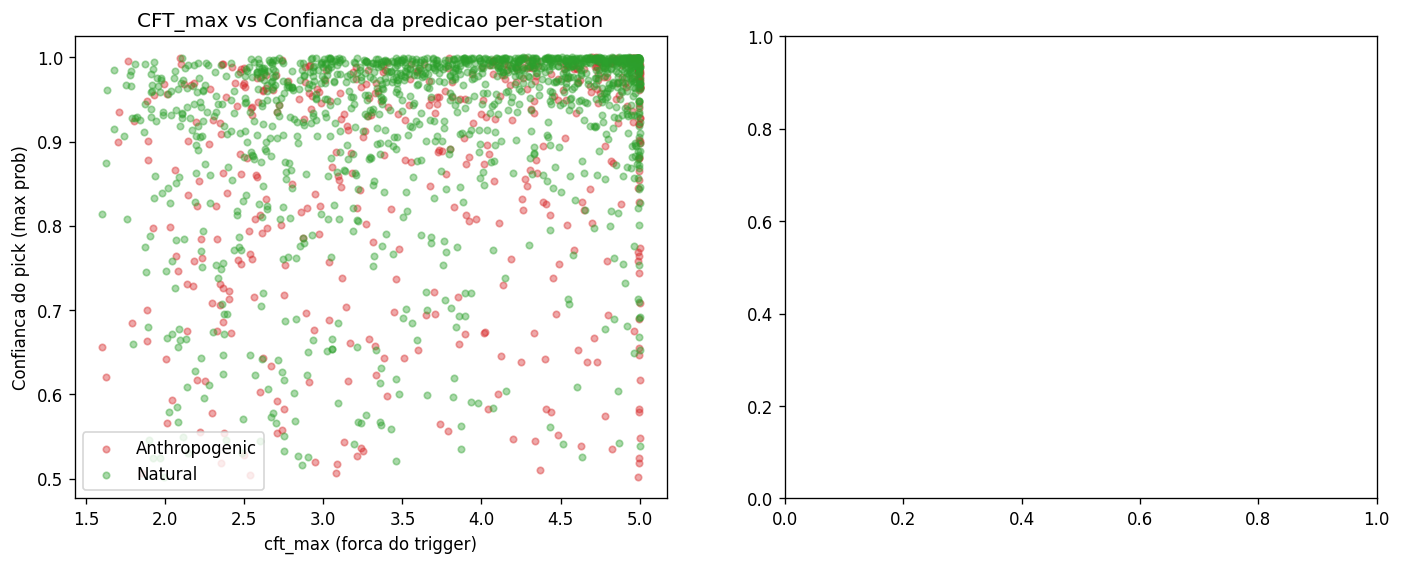

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {"Natural": "#2ca02c", "Anthropogenic": "#d62728"}

# --- Scatter: cft_max vs pick_confidence, colorido por classe ---
for lbl, grp in df_pick.groupby("pick_label"):
    axes[0].scatter(grp["cft_max"], grp["pick_confidence"],
                    c=colors_map.get(lbl, "gray"), label=lbl, alpha=0.4, s=15)
axes[0].set_xlabel("cft_max (forca do trigger)")
axes[0].set_ylabel("Confianca do pick (max prob)")
axes[0].set_title("CFT_max vs Confianca da predicao per-station")
axes[0].legend()

# Correlacao de Pearson
valid = df_pick[["cft_max", "pick_confidence"]].dropna()
r_cft, p_cft = stats.pearsonr(valid["cft_max"], valid["pick_confidence"])
axes[0].text(0.05, 0.95, f"Pearson r={r_cft:.3f}, p={p_cft:.2e}",
             transform=axes[0].transAxes, va="top", fontsize=9,
             bbox=dict(boxstyle="round", fc="white", alpha=0.7))

# --- Box plot: distribuicao de cft_max por classe de predicao ---
df_pick.boxplot(column="cft_max", by="pick_label", ax=axes[1])
axes[1].set_title("Distribuicao de CFT_max por classe")
axes[1].set_xlabel("Classe predita")
axes[1].set_ylabel("cft_max")
plt.suptitle("")  # remover titulo automatico do pandas boxplot

plt.tight_layout()
plt.show()

print(f"Pearson(cft_max, pick_confidence): r={r_cft:.3f}, p={p_cft:.3e}")
print()
print(df_pick.groupby("pick_label")["cft_max"].describe().round(3))


### 12.3 Distancia epicentral vs Confianca e CFT_max

Estacoes mais distantes do epicentro recebem ondas mais atenuadas e com menor
SNR. Isto pode reduzir tanto o cft_max (trigger mais fraco) quanto a confianca
da CNN (espectrograma mais ruidoso).

**Hipotese:** correlacao negativa entre distancia e confianca/cft_max.


In [ ]:
df_dist = df_pick.dropna(subset=["dist_km"])
print(f"Picks com dist_km disponivel: {len(df_dist)} / {len(df_pick)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_map = {"Natural": "#2ca02c", "Anthropogenic": "#d62728"}

# --- 1. Distancia vs Confianca do pick ---
for lbl, grp in df_dist.groupby("pick_label"):
    axes[0].scatter(grp["dist_km"], grp["pick_confidence"],
                    c=colors_map.get(lbl, "gray"), label=lbl, alpha=0.4, s=15)
axes[0].set_xlabel("Distancia epicentral (km)")
axes[0].set_ylabel("Confianca do pick")
axes[0].set_title("Distancia vs Confianca")
axes[0].legend()

r_dc, p_dc = stats.pearsonr(df_dist["dist_km"], df_dist["pick_confidence"])
axes[0].text(0.05, 0.95, f"Pearson r={r_dc:.3f}, p={p_dc:.2e}",
             transform=axes[0].transAxes, va="top", fontsize=9,
             bbox=dict(boxstyle="round", fc="white", alpha=0.7))

# --- 2. Distancia vs CFT_max ---
df_dist2 = df_dist.dropna(subset=["cft_max"])
for lbl, grp in df_dist2.groupby("pick_label"):
    axes[1].scatter(grp["dist_km"], grp["cft_max"],
                    c=colors_map.get(lbl, "gray"), label=lbl, alpha=0.4, s=15)
axes[1].set_xlabel("Distancia epicentral (km)")
axes[1].set_ylabel("cft_max")
axes[1].set_title("Distancia vs CFT_max")
axes[1].legend()

r_dc2, p_dc2 = stats.pearsonr(df_dist2["dist_km"], df_dist2["cft_max"])
axes[1].text(0.05, 0.95, f"Pearson r={r_dc2:.3f}, p={p_dc2:.2e}",
             transform=axes[1].transAxes, va="top", fontsize=9,
             bbox=dict(boxstyle="round", fc="white", alpha=0.7))

# --- 3. Histograma de distancias por classe ---
for lbl, grp in df_dist.groupby("pick_label"):
    axes[2].hist(grp["dist_km"], bins=30, alpha=0.5, label=lbl,
                 color=colors_map.get(lbl, "gray"))
axes[2].set_xlabel("Distancia epicentral (km)")
axes[2].set_ylabel("Numero de picks")
axes[2].set_title("Distribuicao de distancias por classe")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Pearson(dist_km, pick_confidence): r={r_dc:.3f},  p={p_dc:.3e}")
print(f"Pearson(dist_km, cft_max):         r={r_dc2:.3f}, p={p_dc2:.3e}")
print()
print(df_dist.groupby("pick_label")["dist_km"].describe().round(1))


### 12.4 Picks discordantes: estacoes que votam contra o evento

Um pick é "discordante" quando seu label per-station difere do label final do
evento (voto majoritario). Por exemplo: o evento e classificado como Natural,
mas uma estacao individual votou Anthropogenic.

**Perguntas:**
- Picks discordantes tem cft_max sistematicamente menor? (sinal mais fraco → erro)
- Estacoes discordantes estao mais distantes do epicentro?
- Onde eles se concentram no espaco dist_km × cft_max?


Picks concordantes:  1556
Picks discordantes:  237
Taxa de discordancia: 13.2%



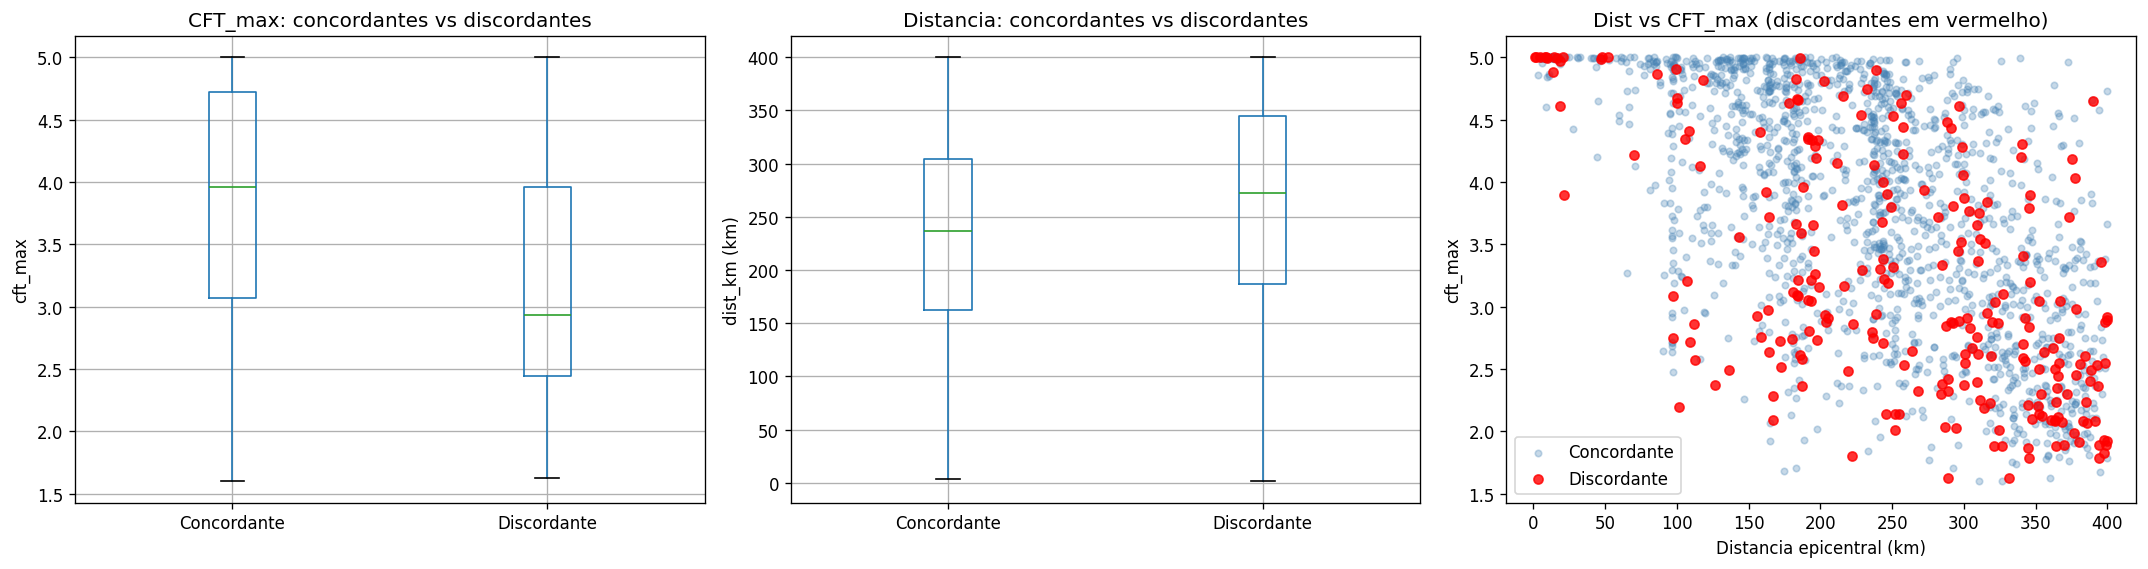


Detalhes dos 237 picks discordantes:
      event_id station    dist_km  cft_max    pick_label   event_label  pick_confidence  event_confidence
2014186T192636   BB19B 287.064739 2.030984 Anthropogenic       Natural         0.798395          0.500308
2014186T192636    BSCB 107.225031 3.208331 Anthropogenic       Natural         0.988267          0.500308
2014186T192636    PARB 235.787279 2.799495 Anthropogenic       Natural         0.850051          0.500308
2014316T135048    ESAR 345.600568 1.784529       Natural Anthropogenic         0.983343          0.500435
2014316T135048   VAS01 319.095914 2.606647       Natural Anthropogenic         0.704432          0.500435
2023218T192408    ITRB 164.342825 2.639797 Anthropogenic       Natural         0.963143          0.503944
2023218T192408    RCLB 300.855093 2.546571 Anthropogenic       Natural         0.760652          0.503944
2023218T192408    PMNB 296.783471 2.886577 Anthropogenic       Natural         0.970444          0.503944
2023218T

In [26]:
df_agree = df_pick[df_pick["agrees_with_event"]]
df_dissent = df_pick[~df_pick["agrees_with_event"]]

n_total = len(df_pick)
n_dissent = len(df_dissent)
print(f"Picks concordantes:  {len(df_agree)}")
print(f"Picks discordantes:  {n_dissent}")
print(f"Taxa de discordancia: {n_dissent / n_total * 100:.1f}%" if n_total > 0 else "")
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Coluna auxiliar para os boxplots (nao persistimos no df original)
tipo = df_pick["agrees_with_event"].map({True: "Concordante", False: "Discordante"})

# --- 1. Box plot: cft_max por concordancia ---
df_pick.assign(tipo=tipo).boxplot(column="cft_max", by="tipo", ax=axes[0])
axes[0].set_title("CFT_max: concordantes vs discordantes")
axes[0].set_xlabel("")
axes[0].set_ylabel("cft_max")

# --- 2. Box plot: dist_km por concordancia ---
df_pick_dist = df_pick.dropna(subset=["dist_km"]).assign(tipo=tipo[df_pick["dist_km"].notna()])
df_pick_dist.boxplot(column="dist_km", by="tipo", ax=axes[1])
axes[1].set_title("Distancia: concordantes vs discordantes")
axes[1].set_xlabel("")
axes[1].set_ylabel("dist_km (km)")

# --- 3. Scatter: dist_km vs cft_max com discordantes em vermelho ---
df_sc = df_pick.dropna(subset=["dist_km", "cft_max"])
mask_agree = df_sc["agrees_with_event"]
axes[2].scatter(df_sc.loc[mask_agree, "dist_km"], df_sc.loc[mask_agree, "cft_max"],
                c="steelblue", alpha=0.3, s=15, label="Concordante")
axes[2].scatter(df_sc.loc[~mask_agree, "dist_km"], df_sc.loc[~mask_agree, "cft_max"],
                c="red", alpha=0.8, s=30, label="Discordante", zorder=5)
axes[2].set_xlabel("Distancia epicentral (km)")
axes[2].set_ylabel("cft_max")
axes[2].set_title("Dist vs CFT_max (discordantes em vermelho)")
axes[2].legend()

plt.suptitle("")
plt.tight_layout()
plt.show()

# --- Tabela dos picks discordantes ---
if n_dissent > 0:
    print(f"\nDetalhes dos {n_dissent} picks discordantes:")
    cols = ["event_id", "station", "dist_km", "cft_max", "pick_label",
            "event_label", "pick_confidence", "event_confidence"]
    print(df_dissent[cols].sort_values("event_confidence").to_string(index=False))
else:
    print("\nNenhum pick discordante encontrado — todas as estacoes concordam com o evento.")


### 12.5 Impacto na classificacao final do evento

Aqui agregamos as metricas per-station ao nivel do evento para investigar se
eventos de **baixa confianca** (< 0.7) tem, sistematicamente:
- Estacoes mais distantes (max_dist_km alto)
- Picks de pior qualidade (min_cft_max baixo)
- Maior fracao de votos discordantes

Isto indicaria que a geometria da rede e/ou a qualidade do sinal estao
degradando o resultado final da CNN em certos eventos.


Eventos agregados: 435
Com confianca < 0.7: 107



NameError: name 'stats' is not defined

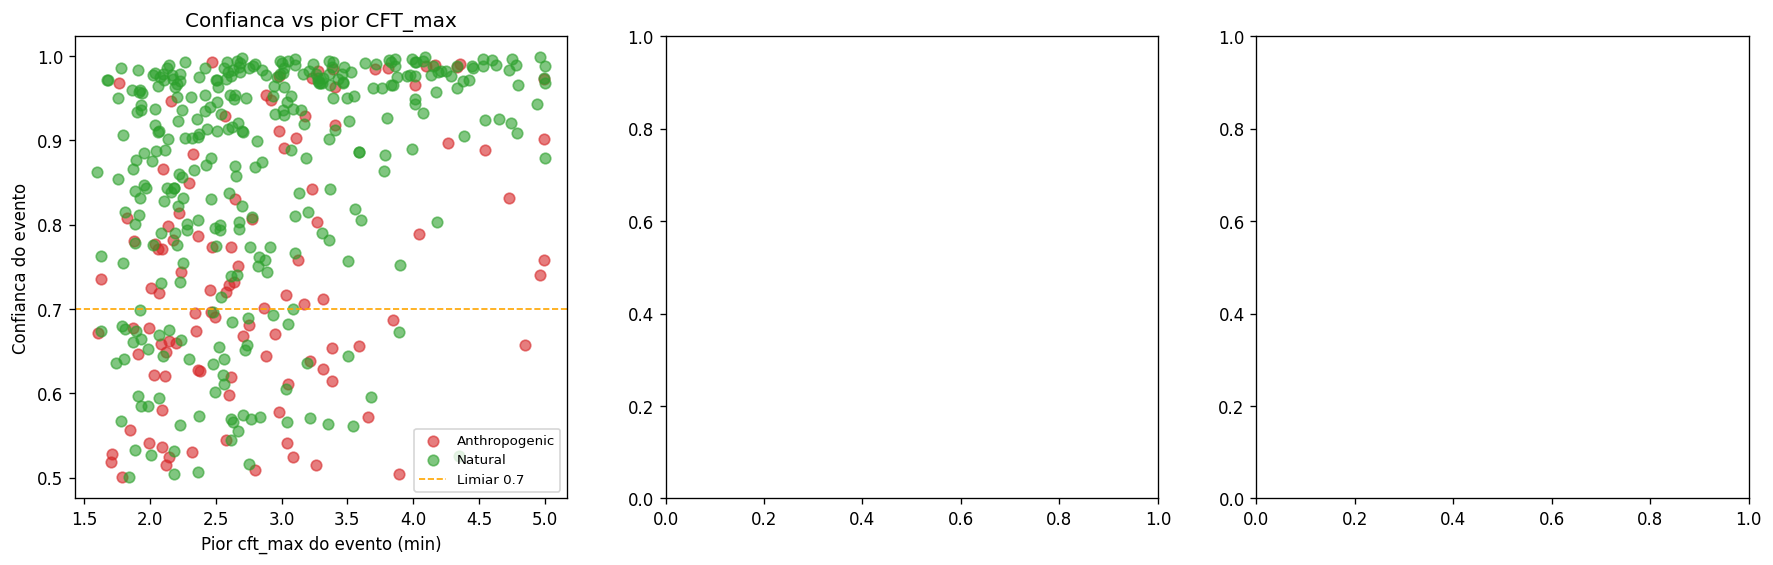

In [27]:
# ---------------------------------------------------------------------------
# Agregar metricas per-station ao nivel do evento
# ---------------------------------------------------------------------------
df_event_agg = df_pick.groupby("event_id").agg(
    event_label=("event_label", "first"),
    event_confidence=("event_confidence", "first"),
    magnitude=("magnitude", "first"),
    max_dist_km=("dist_km", "max"),
    min_cft_max=("cft_max", "min"),
    mean_cft_max=("cft_max", "mean"),
    n_dissenting=("agrees_with_event", lambda x: (~x).sum()),
    n_picks=("agrees_with_event", "count"),
).reset_index()
df_event_agg["dissent_frac"] = df_event_agg["n_dissenting"] / df_event_agg["n_picks"]

print(f"Eventos agregados: {len(df_event_agg)}")
print(f"Com confianca < 0.7: {(df_event_agg['event_confidence'] < 0.7).sum()}")
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_map = {"Natural": "#2ca02c", "Anthropogenic": "#d62728"}

# --- 1. Confianca do evento vs pior cft_max (min) ---
for lbl, grp in df_event_agg.groupby("event_label"):
    axes[0].scatter(grp["min_cft_max"], grp["event_confidence"],
                    c=colors_map.get(lbl, "gray"), label=lbl, alpha=0.6, s=40)
axes[0].set_xlabel("Pior cft_max do evento (min)")
axes[0].set_ylabel("Confianca do evento")
axes[0].set_title("Confianca vs pior CFT_max")
axes[0].axhline(0.7, color="orange", ls="--", lw=1, label="Limiar 0.7")
axes[0].legend(fontsize=8)

valid_cft = df_event_agg.dropna(subset=["min_cft_max"])
r_ec, p_ec = stats.pearsonr(valid_cft["min_cft_max"], valid_cft["event_confidence"])
axes[0].text(0.05, 0.05, f"Pearson r={r_ec:.3f}, p={p_ec:.2e}",
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", fc="white", alpha=0.7))

# --- 2. Confianca do evento vs distancia maxima ---
for lbl, grp in df_event_agg.groupby("event_label"):
    axes[1].scatter(grp["max_dist_km"], grp["event_confidence"],
                    c=colors_map.get(lbl, "gray"), label=lbl, alpha=0.6, s=40)
axes[1].set_xlabel("Distancia maxima da estacao (km)")
axes[1].set_ylabel("Confianca do evento")
axes[1].set_title("Confianca vs distancia maxima")
axes[1].axhline(0.7, color="orange", ls="--", lw=1, label="Limiar 0.7")
axes[1].legend(fontsize=8)

valid_dist = df_event_agg.dropna(subset=["max_dist_km"])
r_ed, p_ed = stats.pearsonr(valid_dist["max_dist_km"], valid_dist["event_confidence"])
axes[1].text(0.05, 0.05, f"Pearson r={r_ed:.3f}, p={p_ed:.2e}",
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", fc="white", alpha=0.7))

# --- 3. Confianca do evento vs fracao de picks discordantes ---
for lbl, grp in df_event_agg.groupby("event_label"):
    axes[2].scatter(grp["dissent_frac"], grp["event_confidence"],
                    c=colors_map.get(lbl, "gray"), label=lbl, alpha=0.6, s=40)
axes[2].set_xlabel("Fracao de picks discordantes")
axes[2].set_ylabel("Confianca do evento")
axes[2].set_title("Confianca vs fracao discordante")
axes[2].axhline(0.7, color="orange", ls="--", lw=1, label="Limiar 0.7")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- Tabela: eventos com confianca < 0.7 ---
low_conf = df_event_agg[df_event_agg["event_confidence"] < 0.7].sort_values("event_confidence")
print(f"\nEventos com confianca < 0.7: {len(low_conf)}")
if len(low_conf) > 0:
    cols = ["event_id", "event_label", "event_confidence", "magnitude",
            "max_dist_km", "min_cft_max", "n_dissenting", "n_picks", "dissent_frac"]
    print(low_conf[cols].round(3).to_string(index=False))

print(f"\n--- Correlacoes ---")
print(f"Pearson(min_cft_max, event_confidence): r={r_ec:.3f}, p={p_ec:.3e}")
print(f"Pearson(max_dist_km, event_confidence): r={r_ed:.3f}, p={p_ed:.3e}")
